# 0. Import library

In [22]:
import platform
import psutil
import torch

print(f"CPU: {platform.processor()}")
print(f"CPU 코어 수: {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count(logical=True)} logical")
print(f"RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")

import subprocess
result = subprocess.run(['cat', '/proc/cpuinfo'], capture_output=True, text=True)
# model name만 추출
for line in result.stdout.split('\n'):
    if 'model name' in line:
        print(line)
        break

CPU: x86_64
CPU 코어 수: 48 physical / 96 logical
RAM: 1007.7 GB
OS: Linux 5.4.0-176-generic
Python: 3.11.11
PyTorch: 2.5.1+cu121
model name	: AMD EPYC 7413 24-Core Processor


In [23]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # 물리적 2번 GPU만 보이게 설정

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")
# 이제 torch.cuda.get_device_name(0)을 하면 물리적 2번 GPU의 이름이 나옵니다.

Current device: cuda


In [24]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


# 1-1. Import Data 

In [25]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


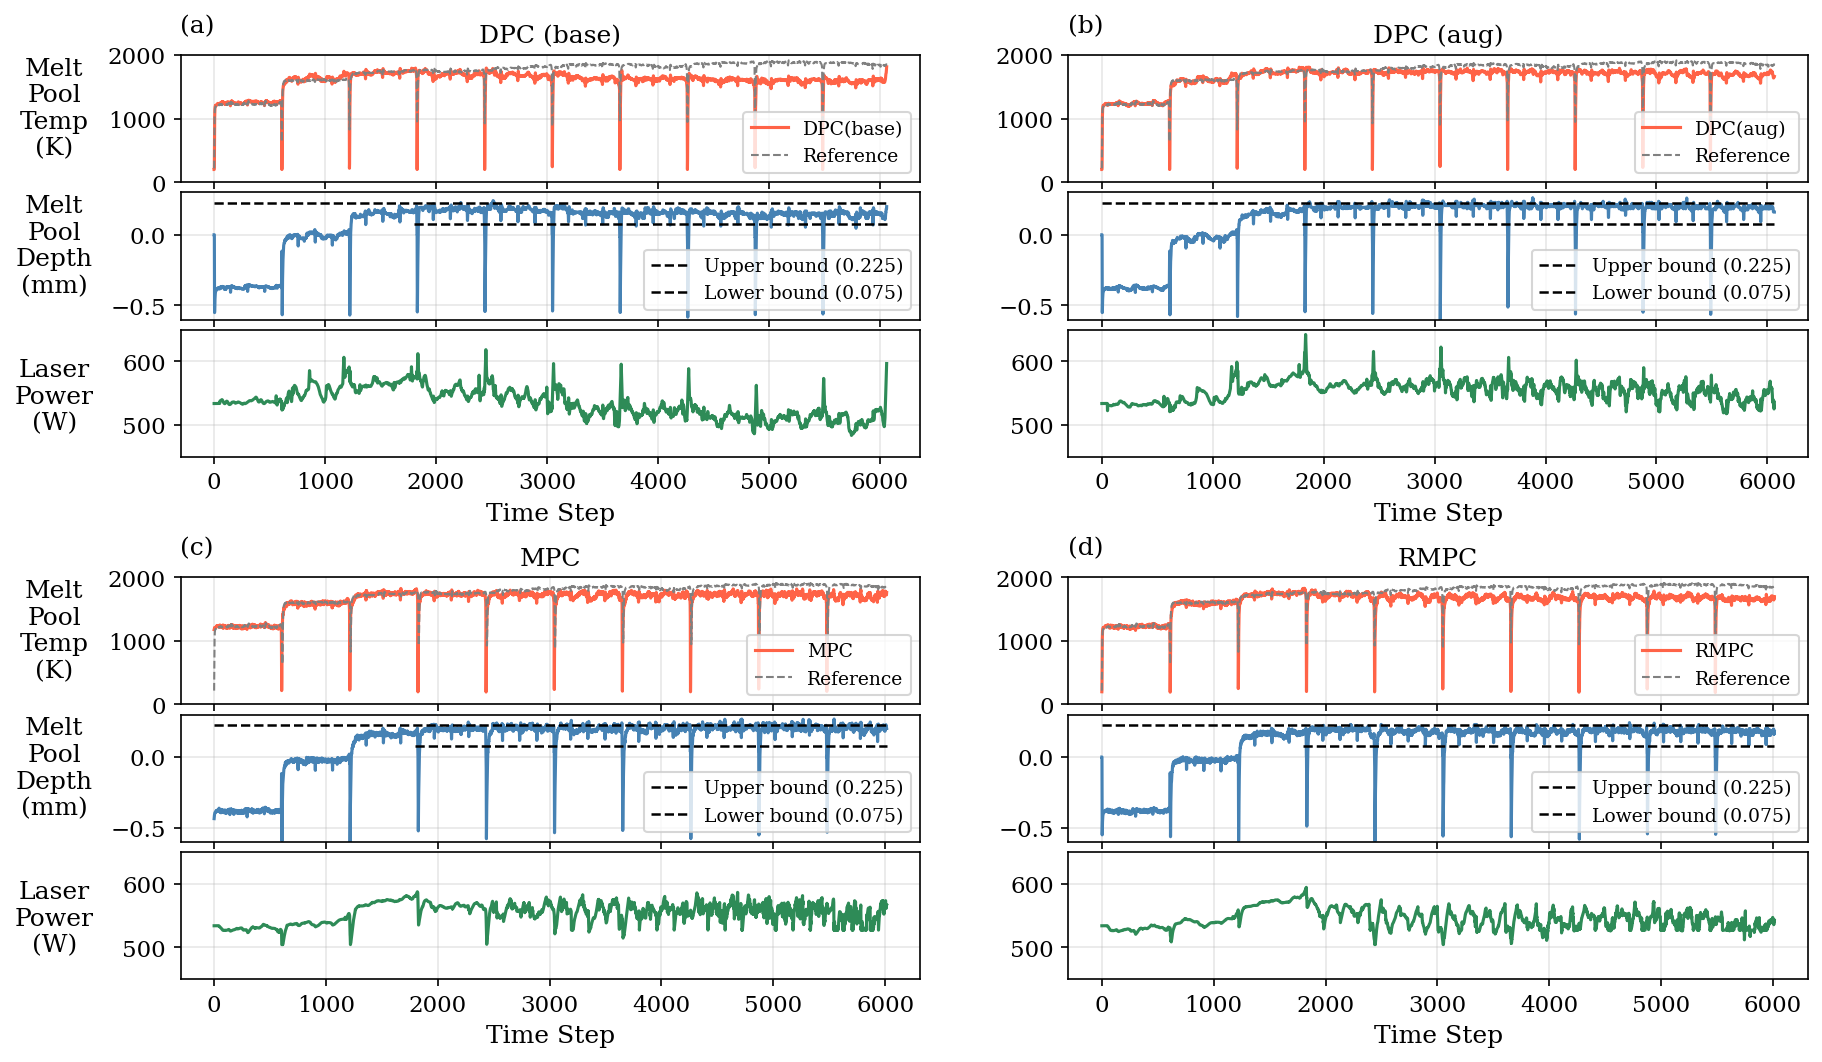

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

lw = 1.5
cutoff = 201 - 20

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
})

# 경로
rmpc_csv = '/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_RMPC_w_depth_control.csv'
mpc_csv  = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_MPC_w_depth_control_0925.csv"

dpc_dir_base = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88base_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_model_best.pth_clamped(1)"

dpc_dir_aug = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_roll_epoch0199.pth_clamped(1)"

# 데이터 로드
def load_dpc(dir_path):
    return (
        pd.read_csv(os.path.join(dir_path, 'x_outputs_laser_1.csv')),
        pd.read_csv(os.path.join(dir_path, 'u_outputs_laser_1.csv')),
        pd.read_csv(os.path.join(dir_path, 'ref_laser_1.csv'))
    )

def process_dpc(df_x, df_u, df_ref):
    temp = df_x.iloc[:,0].values/2
    depth = df_x.iloc[:,1].values
    u = df_u.iloc[:,0].values
    ref = df_ref.iloc[:,0].values/2

    N = min(len(temp), len(u), len(ref)) - cutoff
    t = np.arange(N)

    return t, temp[:N], depth[:N], u[:N], ref[:N]

df_x1, df_u1, df_ref1 = load_dpc(dpc_dir_base)
df_x2, df_u2, df_ref2 = load_dpc(dpc_dir_aug)

t1, temp1, depth1, u1, ref1 = process_dpc(df_x1, df_u1, df_ref1)
t2, temp2, depth2, u2, ref2 = process_dpc(df_x2, df_u2, df_ref2)

df_mpc  = pd.read_csv(mpc_csv).iloc[:-cutoff]
df_rmpc = pd.read_csv(rmpc_csv).iloc[:-cutoff]

# ─────────────────────────────────────
# Figure 구조
# ─────────────────────────────────────
fig = plt.figure(figsize=(14, 8))

outer = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

def make_block(gs):
    inner = gs.subgridspec(3,1, hspace=0.08)
    return [fig.add_subplot(inner[i]) for i in range(3)]

ax_dpc1 = make_block(outer[0,0])
ax_dpc2 = make_block(outer[0,1])
ax_mpc  = make_block(outer[1,0])
ax_rmpc = make_block(outer[1,1])

# ─────────────────────────────────────
# Plot 함수
# ─────────────────────────────────────
def plot_block(axs, t, temp, depth, u, ref, label):
    ax_t, ax_d, ax_u = axs

    # Temperature
    ax_t.plot(t, temp, color='tomato', lw=lw, label=label)
    ax_t.plot(t, ref, '--', color='gray', lw=1.0, label='Reference')
    ax_t.legend(loc='lower right', frameon=True)
    ax_t.grid(True, alpha=0.3)
    ax_t.tick_params(labelbottom=False)
    ax_t.set_ylim(0, 2000)

    # Depth
    ax_d.plot(t, depth, color='steelblue', lw=lw)
    ax_d.grid(True, alpha=0.3)
    ax_d.tick_params(labelbottom=False)
    ax_d.set_ylim(-0.6, 0.3)

    # 🔥 constraint (수정 핵심)
    ax_d.hlines(0.225, 0, t[-1],
                colors='black', linestyles='--', lw=1.2,
                label='Upper bound (0.225)')

    ax_d.hlines(0.075, 1800, t[-1],
                colors='black', linestyles='--', lw=1.2,
                label='Lower bound (0.075)')

    mask = t >= 1800

    ax_d.fill_between(t, depth, 0.075,
                      where=(mask & (depth < 0.075)),
                      color='red', alpha=0.2)

    ax_d.fill_between(t, depth, 0.225,
                      where=(mask & (depth > 0.225)),
                      color='red', alpha=0.2)

    ax_d.legend(loc='lower right', frameon=True)

    # Power
    ax_u.plot(t, u, color='seagreen', lw=lw)
    ax_u.set_xlabel("Time Step")
    ax_u.grid(True, alpha=0.3)
    ax_u.set_ylim(450, 650)

# ─────────────────────────────────────
# Plot
# ─────────────────────────────────────
plot_block(ax_dpc1, t1, temp1, depth1, u1, ref1, "DPC(base)")
plot_block(ax_dpc2, t2, temp2, depth2, u2, ref2, "DPC(aug)")

plot_block(ax_mpc,
           df_mpc.index,
           df_mpc["gamma_result_temp"]/2,
           df_mpc["gamma_result_depth"],
           df_mpc["LP"],
           df_mpc["ref"]/2,
           "MPC")

plot_block(ax_rmpc,
           df_rmpc.index,
           df_rmpc["gamma_result_temp"]/2,
           df_rmpc["gamma_result_depth"],
           df_rmpc["LP"],
           df_rmpc["ref"]/2,
           "RMPC")

# 제목
ax_dpc1[0].set_title("DPC (base)")
ax_dpc2[0].set_title("DPC (aug)")
ax_mpc[0].set_title("MPC")
ax_rmpc[0].set_title("RMPC")

# ─────────────────────────────────────
# 좌측 라벨
# ─────────────────────────────────────
def add_labels(ax_block):
    pos_t = ax_block[0].get_position()
    pos_d = ax_block[1].get_position()
    pos_u = ax_block[2].get_position()

    x = pos_t.x0 - 0.06

    fig.text(x, (pos_t.y0+pos_t.y1)/2-0.03, "Melt\nPool\nTemp\n(K)", ha='center')
    fig.text(x, (pos_d.y0+pos_d.y1)/2-0.03, "Melt\nPool\nDepth\n(mm)", ha='center')
    fig.text(x, (pos_u.y0+pos_u.y1)/2-0.03, "Laser\nPower\n(W)", ha='center')

add_labels(ax_dpc1)
add_labels(ax_mpc)

# ─────────────────────────────────────
# (a)(b)(c)(d) 위치 🔥
# ─────────────────────────────────────
blocks = [ax_dpc1, ax_dpc2, ax_mpc, ax_rmpc]
labels = ['(a)', '(b)', '(c)', '(d)']

for block, lab in zip(blocks, labels):
    pos_top = block[0].get_position()
    pos_bot = block[2].get_position()

    # 🔥 block 전체 영역 기준
    x = pos_top.x0
    y = pos_top.y1 + 0.015   # 🔥 미세 조정 가능

    fig.text(x, y, lab, fontsize=12, ha='left', va='bottom')
# ─────────────────────────────────────
# 전체 위치 미세조정 🔥
# ─────────────────────────────────────

plt.savefig('ex2-3-1.pdf', bbox_inches='tight', dpi=300)
plt.show()

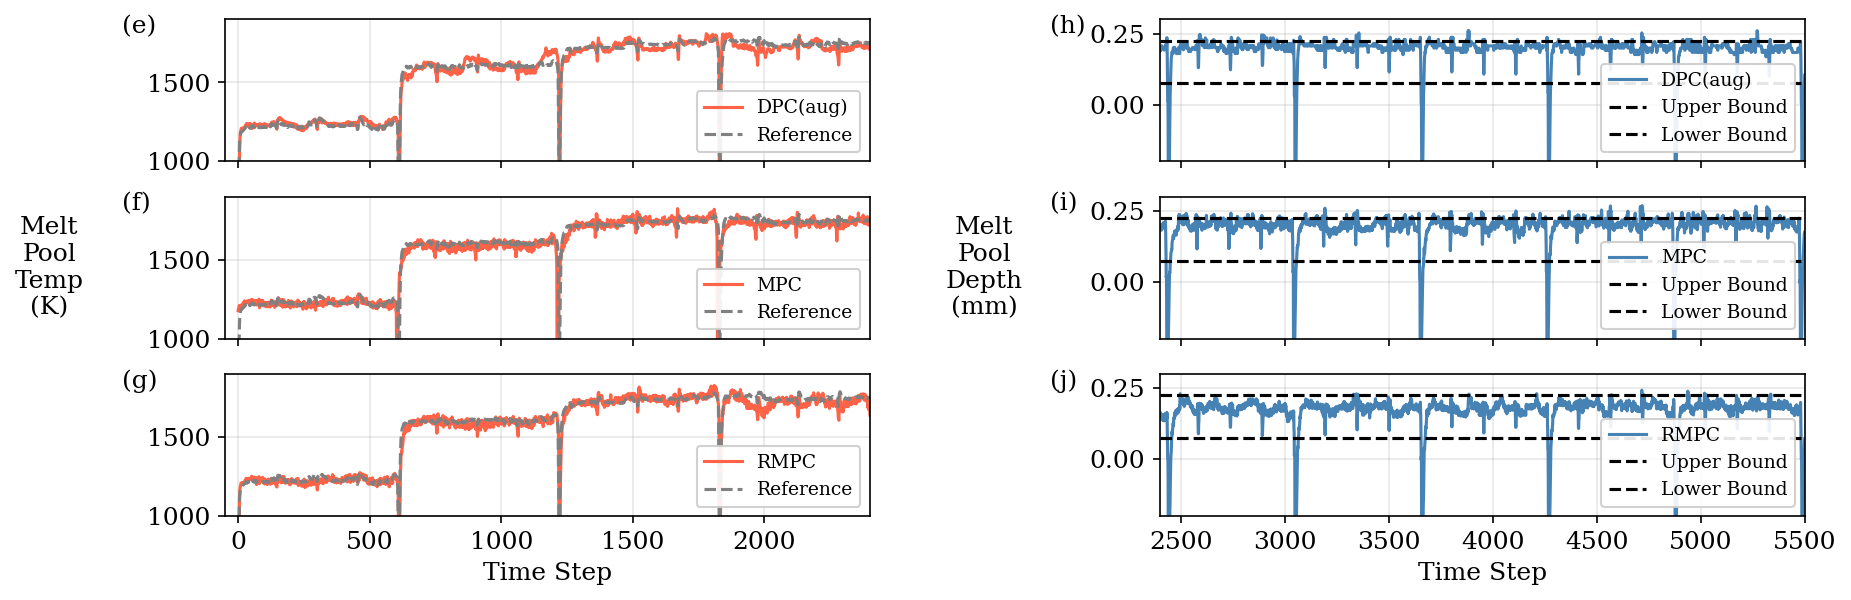

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec

# plt.rcParams.update({
#     "font.family": "serif",
#     "mathtext.fontset": "stix",
#     "font.size": 12,
#     "axes.titlesize": 12,
#     "axes.labelsize": 12,
#     "xtick.labelsize": 11,
#     "ytick.labelsize": 11,
#     "legend.fontsize": 9,
# })

# =========================
# 전체 글씨 크기 설정
# =========================
FONT_SIZE = 12
AXIS_LABEL_SIZE = 12
TICK_SIZE = 12
LEGEND_SIZE = 9
PANEL_LABEL_SIZE = 12
GROUP_YLABEL_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})


def load_data(csv_path_or_dir, laser_num=1):
    if os.path.isdir(csv_path_or_dir):
        x = pd.read_csv(os.path.join(csv_path_or_dir, f"x_outputs_laser_{laser_num}.csv")).values
        ref = pd.read_csv(os.path.join(csv_path_or_dir, f"ref_laser_{laser_num}.csv")).values.flatten()/2
        temp = x[:, 0]/2
        depth = x[:, 1]
    else:
        df = pd.read_csv(csv_path_or_dir)
        temp = df["gamma_result_temp"].values/2
        depth = df["gamma_result_depth"].values
        ref = df["ref"].values/2

    return temp, depth, ref


def plot_EFGHIJ_two_columns(rmpc_path, mpc_path, dpc_path):

    temp_r, depth_r, ref_r = load_data(rmpc_path)
    temp_m, depth_m, ref_m = load_data(mpc_path)
    temp_d, depth_d, ref_d = load_data(dpc_path)

    N = min(len(temp_r), len(temp_m), len(temp_d))
    t = np.arange(N)

    fig = plt.figure(figsize=(13, 4.3))

    # wspace를 키워야 가운데 Depth ylabel 공간 생김
    gs = gridspec.GridSpec(
        3, 2,
        wspace=0.45,
        hspace=0.25
    )

    axes = [
        fig.add_subplot(gs[0, 0]),  # e
        fig.add_subplot(gs[1, 0]),  # f
        fig.add_subplot(gs[2, 0]),  # g
        fig.add_subplot(gs[0, 1]),  # h
        fig.add_subplot(gs[1, 1]),  # i
        fig.add_subplot(gs[2, 1]),  # j
    ]

    labels = ['DPC(aug)', 'MPC', 'RMPC']

    # =========================
    # Temperature: e,f,g
    # =========================
    temps = [temp_d, temp_m, temp_r]
    refs = [ref_d, ref_m, ref_r]

    for i in range(3):
        ax = axes[i]

        ax.plot(t, temps[i][:N], color='tomato', label=labels[i])
        ax.plot(t, refs[i][:N], '--', color='gray', label='Reference')

        ax.set_xlim(-50, 2400)
        ax.set_ylim(1000, 1900)
        ax.grid(True, alpha=0.3)

        if i == 2:
            ax.set_xlabel("Time Step")
        else:
            ax.tick_params(labelbottom=False)

        ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

        ax.text(
            -0.13-0.03, 1.02-0.15,
            f'({chr(101+i)})',
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            ha='left',
            va='bottom'
        )

    # =========================
    # Depth: h,i,j
    # =========================
    depths = [depth_d, depth_m, depth_r]

    for i in range(3):
        ax = axes[i+3]

        ax.plot(t, depths[i][:N], color='steelblue', label=labels[i])

        ax.set_xlim(2400, 5500)
        ax.set_ylim(-0.2, 0.3)

        ax.hlines(0.225, 2400, 5500, linestyle='--', color='black', label='Upper Bound')
        ax.hlines(0.075, 2400, 5500, linestyle='--', color='black', label='Lower Bound')

        ax.grid(True, alpha=0.3)

        if i == 2:
            ax.set_xlabel("Time Step")
        else:
            ax.tick_params(labelbottom=False)

        ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

        ax.text(
            -0.13-0.04, 1.02-0.15,
            f'({chr(104+i)})',
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            ha='left',
            va='bottom'
        )

    # =========================
    # 중요: layout 먼저 조정
    # =========================
    plt.subplots_adjust(
        left=0.16,
        right=0.97,
        top=0.93,
        bottom=0.16
    )

    # =========================
    # 그 다음 y-label 위치 계산
    # =========================
    pos_e = axes[0].get_position()
    pos_g = axes[2].get_position()
    pos_h = axes[3].get_position()
    pos_j = axes[5].get_position()

    # 왼쪽 열 ylabel
    fig.text(
        pos_e.x0 - 0.07-0.02,
        (pos_g.y0 + pos_e.y1) / 2,
        "Melt\nPool\nTemp\n(K)",
        ha='center',
        va='center',
        fontsize=GROUP_YLABEL_SIZE,
        linespacing=1.2
    )

    # 오른쪽 열 ylabel
    fig.text(
        pos_h.x0 - 0.070-0.02,
        (pos_j.y0 + pos_h.y1) / 2,
        "Melt\nPool\nDepth\n(mm)",
        ha='center',
        va='center',
        fontsize=GROUP_YLABEL_SIZE,
        linespacing=1.2
    )
    plt.savefig('ex2-3-2.pdf', bbox_inches='tight', dpi=300)
    plt.show()


if __name__ == "__main__":

    rmpc_csv = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_RMPC_w_depth_control.csv"

    mpc_csv = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_MPC_w_depth_control_0925.csv"

    dpc_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_roll_epoch0199.pth_clamped(1)"

    plot_EFGHIJ_two_columns(rmpc_csv, mpc_csv, dpc_dir)

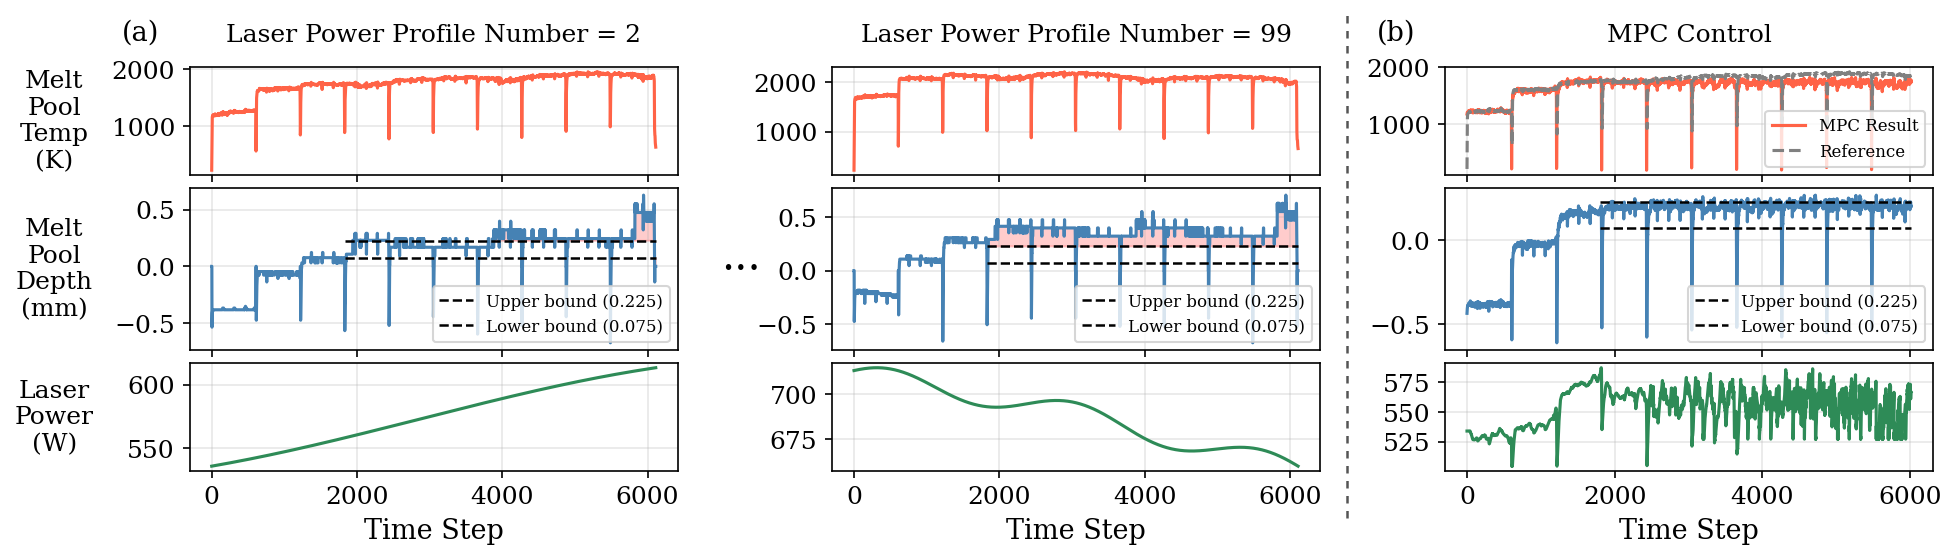

In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

lw = 1.5
cutoff = 201 - 20
las_nums = [2, 99]
df_rmpc = pd.read_csv(mpc_csv).iloc[:-cutoff]


plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

fig = plt.figure(figsize=(15, 3.5))

gs = gridspec.GridSpec(3, 5, figure=fig,
                       width_ratios=[10, -2.5, -2, 10, 10],
                       height_ratios=[2, 3, 2],
                       hspace=0.1, wspace=0.5)

axes_left  = [fig.add_subplot(gs[r, 0]) for r in range(3)]
axes_right = [fig.add_subplot(gs[r, 3]) for r in range(3)]
axes_rmpc  = [fig.add_subplot(gs[r, 4]) for r in range(3)]
ax_mid     = fig.add_subplot(gs[:, 1])


# 중간 ... 표시
ax_mid.axis('off')
ax_mid.text(0.5, 0.5, '···', ha='center', va='center',
            fontsize=20, transform=ax_mid.transAxes)

all_axes = [axes_left, axes_right]

for col_axes, las_num in zip(all_axes, las_nums):

    df_plot = df_all[df_all["laser_power_number"] == las_num].reset_index(drop=True)
    df_plot = df_plot.iloc[::2].reset_index(drop=True)
    df_plot = df_plot.iloc[:-(cutoff // 2)].reset_index(drop=True)
    x_actual = df_plot.index * 2

    mask_z = df_plot["Z"] > 2.5

    col_axes[0].plot(x_actual, df_plot["melt_pool_temperature"]/2, color='tomato', linewidth=lw)
    # col_axes[0].set_title(f"Laser Power Number = {las_num}")
    col_axes[0].grid(True, alpha=0.3)
    col_axes[0].tick_params(labelbottom=False)

    ax = col_axes[1]
    ax.plot(x_actual, df_plot["melt_pool_depth"], color='steelblue', linewidth=lw)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False)

    idx = np.where(mask_z)[0]
    if len(idx) > 0:
        x_min_z, x_max_z = x_actual[idx[0]], x_actual[idx[-1]]
        depth_vals = df_plot["melt_pool_depth"]

        ax.hlines(0.225, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
        ax.hlines(0.075, x_min_z, x_max_z, colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
        ax.fill_between(x_actual, depth_vals, 0.075,
                        where=(mask_z & (depth_vals < 0.075)),
                        color='red', alpha=0.2)
        ax.fill_between(x_actual, depth_vals, 0.225,
                        where=(mask_z & (depth_vals > 0.225)),
                        color='red', alpha=0.2)
        ax.legend(loc='lower right', fontsize=8)

    col_axes[2].plot(x_actual, df_plot["Laser_power"], color='seagreen', linewidth=lw)
    col_axes[2].set_xlabel("Time Step")
    col_axes[2].grid(True, alpha=0.3)

# ylabel 맨 좌측만
axes_left[0].set_ylabel("Melt Pool Temp. (K)")
axes_left[1].set_ylabel("Melt Pool Depth (mm)")
axes_left[2].set_ylabel("Laser Power (W)")

# ── RMPC (col=4) ──
x_rmpc = df_rmpc.index

axes_rmpc[0].plot(x_rmpc, df_rmpc["gamma_result_temp"]/2, color='tomato', linewidth=lw, label='MPC Result')
axes_rmpc[0].plot(x_rmpc, df_rmpc["ref"]/2,               color='gray',   linewidth=lw, linestyle='--', label='Reference')
# axes_rmpc[0].set_title("RMPC Result")
axes_rmpc[0].grid(True, alpha=0.3)
axes_rmpc[0].tick_params(labelbottom=False)
axes_rmpc[0].legend(loc='lower right', fontsize=8)

ax = axes_rmpc[1]
depth_vals_r = df_rmpc["gamma_result_depth"]
ax.plot(x_rmpc, depth_vals_r, color='steelblue', linewidth=lw)
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)

mask_r = x_rmpc >= 1800
ax.hlines(0.225, 1800, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Upper bound (0.225)')
ax.hlines(0.075, 1800, x_rmpc[-1], colors='black', linestyles='--', linewidth=1.2, label='Lower bound (0.075)')
ax.fill_between(x_rmpc, depth_vals_r, 0.075,
                where=(mask_r & (depth_vals_r < 0.075)), color='red', alpha=0.2)
ax.fill_between(x_rmpc, depth_vals_r, 0.225,
                where=(mask_r & (depth_vals_r > 0.225)), color='red', alpha=0.2)
ax.legend(loc='lower right', fontsize=8)

axes_rmpc[2].plot(x_rmpc, df_rmpc["LP"], color='seagreen', linewidth=lw)
axes_rmpc[2].set_xlabel("Time Step")
axes_rmpc[2].grid(True, alpha=0.3)

pos = axes_right[0].get_position()
x_line = pos.x1 + 0.012  # 0.02 만큼 우측으로 떨어뜨리기

from matplotlib.lines import Line2D
line = Line2D(
    [x_line, x_line], [0.02, 0.98],
    transform=fig.transFigure,
    color='#555555',
    linewidth=1.2,
    linestyle=(0, (3, 3))   # 🔥 더 깔끔한 점선
)
fig.add_artist(line)

plt.tight_layout()


titles = [
    "Laser Power Profile Number = 2",
    "Laser Power Profile Number = 99",
    "MPC Control"
]

# 각 column의 top axes 가져오기
top_axes = [axes_left[0], axes_right[0], axes_rmpc[0]]

for ax, title in zip(top_axes, titles):
    pos = ax.get_position()

    fig.text(
        (pos.x0 + pos.x1) / 2,   # 가운데 정렬
        pos.y1 + 0.04,           # 위로 띄우기 (값 조절 가능)
        title,
        ha='center',
        va='bottom',
        fontsize=12,
    )

# axes_left ylabel 제거
axes_left[0].set_ylabel("")
axes_left[1].set_ylabel("")
axes_left[2].set_ylabel("")

# figure 좌표계에서 좌측 정렬로 직접 배치
pos0 = axes_left[0].get_position()
pos1 = axes_left[1].get_position()
pos2 = axes_left[2].get_position()
x_label = pos0.x0 - 0.05  # 좌측으로 얼마나 떨어질지

fig.text(x_label-0.01, (pos0.y0 + pos0.y1) / 2,
         "Melt\nPool\nTemp\n(K)",
         ha='center', va='center', rotation=0, fontsize=12)

fig.text(x_label-0.01, (pos1.y0 + pos1.y1) / 2,
         "Melt\nPool\nDepth\n(mm)",
         ha='center', va='center', rotation=0, fontsize=12)

fig.text(x_label-0.01, (pos2.y0 + pos2.y1) / 2,
         "Laser\nPower\n(W)",
         ha='center', va='center', rotation=0, fontsize=12)

for ax, label in zip(
    [axes_left[0], axes_right[0], axes_rmpc[0]],
    ['(a)', '', '(b)']
):
    pos = ax.get_position()  # axes 위치 (figure 기준)
    
    fig.text(
        pos.x0 - 0.03,           # 왼쪽
        pos.y1 + 0.04,    # 살짝 위로
        label,
        ha='left',
        va='bottom',
        fontsize=13
    )
    
plt.savefig('ex2-1.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 1-2. Normalize data

In [29]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [30]:
class scalers():
    def __init__(self,x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max
        self.x_min = x_min
        self.y_max = y_max
        self.y_min = y_min
        
        return None
    
    def scaler_x(self, x_original, dim_id = -1):
        if dim_id == -1:
            x_s = -1 + 2 * ((x_original - self.x_min) / (self.x_max-self.x_min))
            return x_s
        else: 
            x_s = -1 + 2 * (x_original - self.x_min[0,dim_id]) / (self.x_max[0,dim_id] - self.x_min[0,dim_id])
            return x_s
    
    def inv_scaler_x(self, x_s, dim_id = -1):
        
        if dim_id == -1:
            x_original = (x_s + 1)*0.5*(self.x_max-self.x_min) + self.x_min
            return x_original
        else: 
            x_original = (x_s + 1)*0.5*(self.x_max[0,dim_id] - self.x_min[0,dim_id]) + self.x_min[0,dim_id]
            return x_original
        
    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max-self.y_min))
    
    def inv_scaler_y(self, y_s):
        return (y_s + 1)*0.5*(self.y_max-self.y_min) + self.y_min

In [31]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original_scale)
y_s = scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))

print("x_s shape:", x_s.shape)
print("y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4)
y_s shape: (610417, 2)


## 1-3. Generate data

In [32]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

e = 0.0001
y_depth_low = np.random.uniform(0.1423-e, 0.1423+e, size = (length,1))
y_depth_up = np.random.uniform(0.4126-e, 0.4126+e, size = (length,1))
# constraints!
#y_depth_low = 0*np.random.uniform(0.0, 0.5, size=(length, 1))
#y_depth_up = 0*np.random.uniform(0.5, 1.0, size=(length, 1))

y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [33]:
import numpy as np
import pandas as pd
import torch
import copy
from tqdm import tqdm

# =====================================================
# 1. Load & preprocess raw data
# =====================================================
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')

print(df_all.shape)
print(df_all.columns)

# ---- global time index (핵심) ----
df_all = df_all.reset_index(drop=True)
df_all["time_id"] = np.arange(len(df_all))

# ---- NaN handling (time_id 유지) ----
nan_rows = df_all[df_all.isna().any(axis=1)]
df_all = df_all.dropna().reset_index(drop=True)

# =====================================================
# 2. Feature extraction
# =====================================================
loc_Z = df_all["Z"].to_numpy().reshape(-1, 1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1, 1)

# ---- global time id ----
time_id_all = df_all["time_id"].to_numpy()

# =====================================================
# 3. Melt pool smoothing
# =====================================================
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw, 4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1, 1)

mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw, 4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1, 1)

# =====================================================
# 4. Stack original-scale arrays
# =====================================================
x_original = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)  # (N,4)
y_original = np.concatenate((mp_temp, mp_depth), axis=1)                  # (N,2)

# =====================================================
# 5. Scaling (-1 ~ 1)
# =====================================================
x_max = np.max(x_original, axis=0, keepdims=True)
x_min = np.min(x_original, axis=0, keepdims=True)
y_max = np.max(y_original, axis=0, keepdims=True)
y_min = np.min(y_original, axis=0, keepdims=True)

scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original)
y_s = scaler.scaler_y(y_original)

# =====================================================
# 6. Reference / Constraint (global arrays)
# =====================================================
length = y_s.shape[0]

# =====================================================
# Global reference (temperature)
# =====================================================
y_ref_global = y_s[:, 0:1]   # (N, 1)


# depth constraint (global)
e = 1e-4
y_depth_low = np.random.uniform(0.1423 - e, 0.1423 + e, size=(length, 1))
y_depth_up  = np.random.uniform(0.4126 - e, 0.4126 + e, size=(length, 1))
y_const_global = np.concatenate((y_depth_low, y_depth_up), axis=1)  # (N,2)

# =====================================================
# 7. Train / Validation split (time-consistent)
# =====================================================
cutoff_index = int(np.round(0.8 * length))

x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val,   y_val   = x_s[cutoff_index:], y_s[cutoff_index:]

time_id_train = time_id_all[:cutoff_index]
time_id_val   = time_id_all[cutoff_index:]

# =====================================================
# 7. (삭제/변경) Train/Val split을 먼저 하지 말고
#    8번에서 전체 샘플을 먼저 만든 뒤 shuffle split
# =====================================================

window = 50
P = 50
N = length

# 전체에서 만들 수 있는 샘플 개수
# i는 "현재 시점(start of future)" 인덱스
# i는 [window, N-P) 범위
n_all = (N - P) - window

x_past_all = np.empty((n_all, window, 4))
y_past_all = np.empty((n_all, window, 2))
x_future_all = np.empty((n_all, P, 3))
y_ref_all_seq = np.empty((n_all, P, 1))
y_const_all_seq = np.empty((n_all, P, 2))
time_idx_all_seq = np.empty(n_all, dtype=np.int64)

for i in tqdm(range(window, N - P)):
    j = i - window

    x_past_all[j] = x_s[i-window:i]
    y_past_all[j] = y_s[i-window:i]
    x_future_all[j] = x_s[i:i+P, :3]

    # reference
    scalar_shift = 0
    y_ref_all_seq[j] = y_ref_global[i:i+P] + scalar_shift

    # constraint
    y_const_all_seq[j] = y_const_global[i:i+P]

    # time index (글로벌)
    time_idx_all_seq[j] = time_id_all[i]

# =====================================================
# 8. Shuffle 후 8:2 split (샘플 단위)
# =====================================================
rng = np.random.default_rng(42)  # 재현성
perm = rng.permutation(n_all)

cut = int(np.round(0.8 * n_all))
train_idx = perm[:cut]
val_idx   = perm[cut:]

x_past_train = x_past_all[train_idx]
y_past_train = y_past_all[train_idx]
x_future_train = x_future_all[train_idx]
y_ref_train_seq = y_ref_all_seq[train_idx]
y_const_train_seq = y_const_all_seq[train_idx]
time_idx_train = time_idx_all_seq[train_idx]

x_past_val = x_past_all[val_idx]
y_past_val = y_past_all[val_idx]
x_future_val = x_future_all[val_idx]
y_ref_val_seq = y_ref_all_seq[val_idx]
y_const_val_seq = y_const_all_seq[val_idx]
time_idx_val = time_idx_all_seq[val_idx]

# =====================================================
# 9. Torch tensor conversion
# =====================================================
x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)
time_idx_train = torch.tensor(time_idx_train, dtype=torch.long)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)
time_idx_val = torch.tensor(time_idx_val, dtype=torch.long)


# =====================================================
# 10. Shape check
# =====================================================
print("Train shapes:")
print("x_past:", x_past_train.shape)
print("y_past:", y_past_train.shape)
print("x_future:", x_future_train.shape)
print("y_ref:", y_ref_train_seq.shape)
print("y_const:", y_const_train_seq.shape)
print("time_idx:", time_idx_train.shape)

print("\nVal shapes:")
print("x_past:", x_past_val.shape)
print("y_past:", y_past_val.shape)
print("x_future:", x_future_val.shape)
print("y_ref:", y_ref_val_seq.shape)
print("y_const:", y_const_val_seq.shape)
print("time_idx:", time_idx_val.shape)


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


100%|██████████| 610317/610317 [00:03<00:00, 179726.57it/s]


Train shapes:
x_past: torch.Size([488254, 50, 4])
y_past: torch.Size([488254, 50, 2])
x_future: torch.Size([488254, 50, 3])
y_ref: torch.Size([488254, 50, 1])
y_const: torch.Size([488254, 50, 2])
time_idx: torch.Size([488254])

Val shapes:
x_past: torch.Size([122063, 50, 4])
y_past: torch.Size([122063, 50, 2])
x_future: torch.Size([122063, 50, 3])
y_ref: torch.Size([122063, 50, 1])
y_const: torch.Size([122063, 50, 2])
time_idx: torch.Size([122063])


In [34]:
batch_size = 256

# ------------------ Training loader ------------------
train_dataset = TensorDataset(
    x_past_train,
    y_past_train,
    x_future_train,
    y_ref_train_seq,
    y_const_train_seq,
    time_idx_train          # ⭐ 반드시 포함
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True           # ⭐ 핵심 수정
)

# ------------------ Validation loader ------------------
val_dataset = TensorDataset(
    x_past_val,
    y_past_val,
    x_future_val,
    y_ref_val_seq,
    y_const_val_seq,
    time_idx_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 3. Import TiDE and Policy Model

In [35]:
# import torch
# import pickle

# # Load model
# with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
#     nominal_params = pickle.load(file)

# TiDE = nominal_params['model'].to(device)
# total_params = sum(p.numel() for p in TiDE.parameters())

import os
import torch
import pickle
import io

# 1. GPU 설정 (커널 리스타트 후 첫 셀에서 실행 권장)
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 장치: {device}")

# 2. 안전한 언피클러 정의 (무조건 CPU로 먼저 로드)
class Safe_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            # 파일에 어떤 장치가 기록되어 있든 상관없이 우선 CPU로 읽어들임
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

# 3. 모델 로드 (에러 발생 지점)
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    # Safe_Unpickler를 사용하여 CPU로 로드
    nominal_params = Safe_Unpickler(file).load()

# 4. 이제 로드된 모델만 GPU(2번)로 이동
TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())

print(f"성공: 모델이 CPU를 거쳐 {device}로 안전하게 로드되었습니다.")
print(f"Total parameters: {total_params}")

현재 사용 중인 장치: cuda
성공: 모델이 CPU를 거쳐 cuda로 안전하게 로드되었습니다.
Total parameters: 796594


# 4. Rollout

In [36]:
import random
import copy
import torch
from torch.utils.data import Dataset

# =========================
# Aug samples wrapper
# =========================
class ListDataset(Dataset):
    """
    aug_samples: list of tuples
      (x_past, y_past, x_future, y_ref, y_const, time_idx)
    """
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# =========================
# Build mapping: time_idx -> base sample index
# =========================
def build_time_to_sample_index(time_idx_tensor: torch.Tensor):
    """
    time_idx_tensor: shape (n_train,), dtype long
    returns: dict { int(time_idx) : int(sample_idx) }
    """
    time_to_j = {}
    # time_idx_tensor is on CPU typically; ensure it is
    t = time_idx_tensor.detach().cpu().tolist()
    for j, tid in enumerate(t):
        time_to_j[int(tid)] = int(j)
    return time_to_j



@torch.no_grad()
def rollout_k_step_augment_m(
    policy_model,
    tide_model,
    # base tensors (windowed training arrays)
    x_past_train,         # (N, window, 4)
    y_past_train,         # (N, window, 2)
    x_future_train,       # (N, P, 3)
    y_ref_train_seq,      # (N, P, 1)
    y_const_train_seq,    # (N, P, 2)
    time_idx_train,       # (N,)
    time_to_j,            # dict: time_idx -> j
    m: int,
    device,
    step: int = 50,
    max_tries_factor: int = 20,
    seed: int = None
):
    """
    K-step rollout augmentation.

    - step 만큼 한 번에 rollout
    - past window를 step만큼 전진
    - future는 실제 데이터(t+step)에서 가져옴

    Returns:
      new_samples: list of tuples
    """

    # =========================
    # 🔥 seed 고정 (핵심)
    # =========================
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    policy_model.eval()
    tide_model.eval()

    n, window, _ = x_past_train.shape
    P = x_future_train.shape[1]

    if n == 0 or m <= 0:
        return []

    # =========================
    # sanity check
    # =========================
    if step <= 0:
        raise ValueError(f"step must be positive, got {step}")
    if step > P:
        raise ValueError(f"step ({step}) cannot exceed P ({P})")
    if step > window:
        raise ValueError(f"step ({step}) cannot exceed window ({window})")

    new_samples = []
    tries = 0
    max_tries = max_tries_factor * m

    # =========================
    # main loop
    # =========================
    while len(new_samples) < m and tries < max_tries:
        tries += 1

        # 🔥 random sampling (seed 영향 받는 부분)
        j = random.randrange(n)

        t_cur = int(time_idx_train[j].item())
        t_next = t_cur + step

        # future 존재 여부 확인
        if t_next not in time_to_j:
            continue

        j_next = time_to_j[t_next]

        # =========================
        # current sample
        # =========================
        x_past = x_past_train[j:j+1].to(device)   # (1, w, 4)
        y_past = y_past_train[j:j+1].to(device)   # (1, w, 2)

        x_future = x_future_train[j:j+1].to(device)
        y_ref = y_ref_train_seq[j:j+1].to(device)
        y_const = y_const_train_seq[j:j+1].to(device)

        # =========================
        # policy forward
        # =========================
        policy_in_past = torch.cat((x_past, y_past), dim=2)
        policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)

        u_seq = policy_model((policy_in_past, policy_in_future))  # (1, P, 1)

        # =========================
        # dynamics (TiDE)
        # =========================
        x_future_tide = torch.cat((x_future, u_seq), dim=2)
        past_cov = torch.cat((y_past, x_past), dim=2)

        tide_pred = tide_model((past_cov, x_future_tide, None))

        # =========================
        # step slice
        # =========================
        u_step = u_seq[:, :step, :]
        yhat_step = tide_pred.median(dim=-1).values[:, :step, :]

        # covariate + control
        x_step = torch.cat((x_future[:, :step, :], u_step), dim=2)

        # =========================
        # window shift
        # =========================
        x_past_new = torch.cat((x_past[:, step:, :], x_step), dim=1)
        y_past_new = torch.cat((y_past[:, step:, :], yhat_step), dim=1)

        # =========================
        # next future (real data)
        # =========================
        x_future_next = x_future_train[j_next].detach().cpu()
        y_ref_next = y_ref_train_seq[j_next].detach().cpu()
        y_const_next = y_const_train_seq[j_next].detach().cpu()

        # =========================
        # save
        # =========================
        new_samples.append((
            x_past_new.squeeze(0).cpu(),
            y_past_new.squeeze(0).cpu(),
            x_future_next,
            y_ref_next,
            y_const_next,
            torch.tensor(t_next, dtype=torch.long)
        ))

    return new_samples

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from policy import PolicyNN

# =========================
# SEED
# =========================
SEED = 123 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# CONSTANTS
# =========================
STEP = 50
N_ROLLS = 6
P = 50
window = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# 🔥 MULTI POLICY LOAD
# =========================
base_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/"
model_epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]

model_paths = [f"{base_path}policy_roll_epoch{ep}.pth" for ep in model_epochs]

models = []

for i, path in enumerate(model_paths):
    print(f"🔹 Loading model {i}: {path}")

    m = PolicyNN(
        past_input_dim=6,
        future_input_dim=6,
        output_dim=1,
        p=P,
        window=window,
        hidden_dim=1024,
        n_layers=3,
        dropout_p=0.0
    ).to(device)

    ckpt = torch.load(path, map_location=device)

    if isinstance(ckpt, dict) and "model_state_dict" not in ckpt:
        m.load_state_dict(ckpt)
    else:
        m.load_state_dict(ckpt["model_state_dict"])

    m.eval()
    models.append(m)

print(f"✅ Loaded {len(models)} policy models")

# =========================
# utils
# =========================
time_to_j = build_time_to_sample_index(time_idx_train)

def to_np(t):
    return t.cpu().numpy() if torch.is_tensor(t) else np.asarray(t)

time_to_global = {int(tid): i for i, tid in enumerate(time_id_all)}

def get_future_from_global(t_start):
    if t_start not in time_to_global:
        return None, None, None

    g_idx = time_to_global[t_start]
    if g_idx + P > len(x_s):
        return None, None, None

    x_future = torch.tensor(x_s[g_idx:g_idx+P, :3], dtype=torch.float32)
    y_ref    = torch.tensor(y_s[g_idx:g_idx+P, 0:1], dtype=torch.float32)
    y_const  = torch.tensor(y_const_global[g_idx:g_idx+P], dtype=torch.float32)
    return x_future, y_ref, y_const

# =========================
# rollout
# =========================
def rollout_one_step(s, model, TiDE, device, STEP):
    x_past_s = s[0].unsqueeze(0).to(device)
    y_past_s = s[1].unsqueeze(0).to(device)

    t_cur  = int(s[5].item())
    t_next = t_cur + STEP

    x_future_s, y_ref_s, y_const_s = get_future_from_global(t_cur)
    if x_future_s is None:
        return None

    x_future_s = x_future_s.unsqueeze(0).to(device)
    y_ref_s    = y_ref_s.unsqueeze(0).to(device)
    y_const_s  = y_const_s.unsqueeze(0).to(device)

    with torch.no_grad():
        policy_in_past   = torch.cat((x_past_s, y_past_s), dim=2)
        policy_in_future = torch.cat((x_future_s, y_ref_s, y_const_s), dim=2)

        u_seq = model((policy_in_past, policy_in_future))

        x_future_tide = torch.cat((x_future_s, u_seq), dim=2)
        past_cov      = torch.cat((y_past_s, x_past_s), dim=2)
        tide_pred     = TiDE((past_cov, x_future_tide, None))

    u_step     = u_seq[:, :STEP, :]
    yhat_step  = tide_pred.median(dim=-1).values[:, :STEP, :]
    x_step     = torch.cat((x_future_s[:, :STEP, :], u_step), dim=2)

    x_past_new = torch.cat((x_past_s[:, STEP:, :], x_step), dim=1)
    y_past_new = torch.cat((y_past_s[:, STEP:, :], yhat_step), dim=1)

    x_future_next, y_ref_next, y_const_next = get_future_from_global(t_next)
    if x_future_next is None:
        return None

    return (
        x_past_new.squeeze(0).cpu(),
        y_past_new.squeeze(0).cpu(),
        x_future_next, y_ref_next, y_const_next,
        torch.tensor(t_next, dtype=torch.long)
    )

# =========================
# 🔥 rollout chain (multi policy)
# =========================
def build_rollout_chain(sample, models, TiDE, device, STEP, N_ROLLS):
    chain = [sample]
    cur = sample

    for k in range(N_ROLLS - 1):
        current_model = models[min(k, len(models)-1)]
        nxt = rollout_one_step(cur, current_model, TiDE, device, STEP)

        if nxt is None:
            break

        chain.append(nxt)
        cur = nxt

    return chain

# =========================
# initial rollout
# =========================
aug_samples = rollout_k_step_augment_m(
    policy_model=models[0],
    tide_model=TiDE,
    x_past_train=x_past_train,
    y_past_train=y_past_train,
    x_future_train=x_future_train,
    y_ref_train_seq=y_ref_train_seq,
    y_const_train_seq=y_const_train_seq,
    time_idx_train=time_idx_train,
    time_to_j=time_to_j,
    m=80,
    device=device,
    step=STEP,
    seed=12
)

# =========================
# filtering
# =========================
samples_with_chain = []
for s in aug_samples:
    chain = build_rollout_chain(s, models, TiDE, device, STEP, N_ROLLS)
    if len(chain) >= 2:
        loc_z = to_np(s[0])[-1, 0]
        samples_with_chain.append((loc_z, s, chain))

samples_with_chain = sorted(samples_with_chain, key=lambda x: x[0])

# =========================
# 🔥 loc-z별 하나씩만 선택
# =========================
z_bins = np.linspace(-0.8, 1.0, 10)

selected_samples = []

for i in range(len(z_bins)-1):
    z_min, z_max = z_bins[i], z_bins[i+1]

    candidates = [s for s in samples_with_chain if z_min <= s[0] < z_max]

    if len(candidates) == 0:
        continue

    selected_samples.append(candidates[0])  # or random.choice(candidates)

samples_with_chain = selected_samples

depth_lower_const = 0.075
depth_upper_const = 0.225

ordinals = ['0th', '1st', '2nd', '3rd', '4th', '5th', '6th']



# =========================
# 🔥 ONLY SAMPLE 5
# =========================
i = min(5, len(samples_with_chain)-1)
loc_z, sample, rollout_chain = samples_with_chain[i]

print(f"Showing sample {i} / total {len(samples_with_chain)}")

t_first = int(sample[5].item())
t_orig  = t_first - STEP

if t_orig not in time_to_j:
    raise ValueError("invalid index")

j_orig = time_to_j[t_orig]

orig_sample = (
    x_past_train[j_orig].cpu(),
    y_past_train[j_orig].cpu(),
    x_future_train[j_orig].cpu(),
    y_ref_train_seq[j_orig].cpu(),
    y_const_train_seq[j_orig].cpu(),
    torch.tensor(t_orig, dtype=torch.long)
)

rollout_chain = [orig_sample] + rollout_chain
n_cols = len(rollout_chain) - 1

# =========================
# 🔥 stitched storage
# =========================
t_all, temp_all, depth_all, u_all, ref_all = [], [], [], [], []

for col in range(n_cols):

    prev_s = rollout_chain[col]
    next_s = rollout_chain[col+1]

    # scale 복원
    y_prev = scaler.inv_scaler_y(to_np(prev_s[1]))
    y_next = scaler.inv_scaler_y(to_np(next_s[1]))
    y_ref  = scaler.inv_scaler_y(to_np(prev_s[3]))

    u_prev = scaler.inv_scaler_x(to_np(prev_s[0])[:, -1], dim_id=3)
    u_next = scaler.inv_scaler_x(to_np(next_s[0])[:, -1], dim_id=3)

    t_left  = np.arange(col*STEP, (col+1)*STEP)
    t_right = np.arange((col+1)*STEP, (col+2)*STEP)

    if col == 0:
        t_all.extend(t_left)
        temp_all.extend(y_prev[:,0])
        depth_all.extend(y_prev[:,1])
        u_all.extend(u_prev)

    t_all.extend(t_right)
    temp_all.extend(y_next[:,0])
    depth_all.extend(y_next[:,1])
    u_all.extend(u_next)
    ref_all.extend(y_ref[:,0])


Using device: cuda
🔹 Loading model 0: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0049.pth
🔹 Loading model 1: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0099.pth
🔹 Loading model 2: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/policy_roll_epoch0149.pth
🔹 Loading model 3: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88a

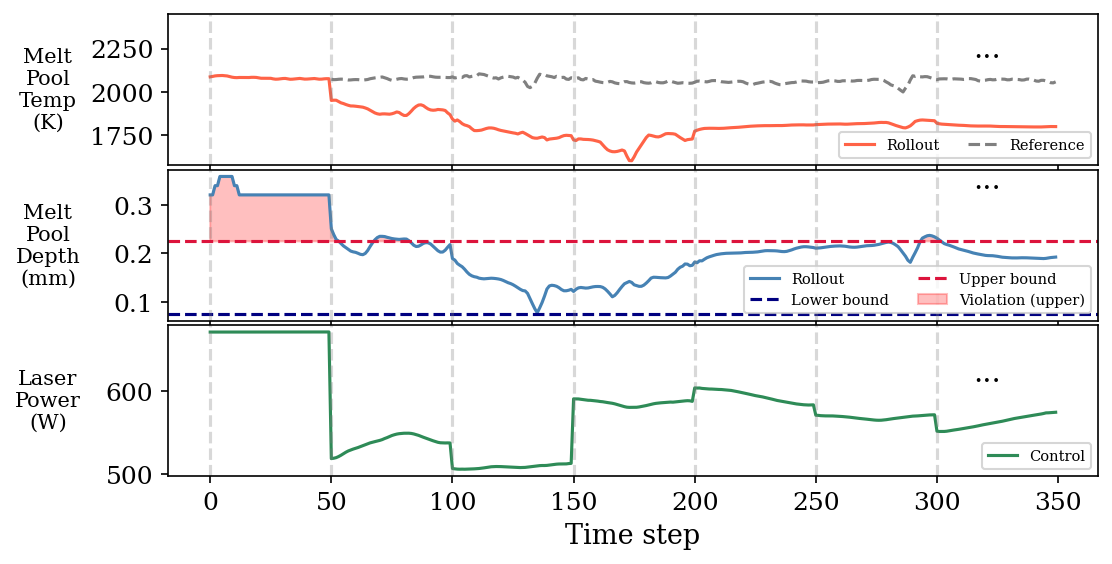

In [38]:
import numpy as np

depth_all = np.array(depth_all)
temp_all = np.array(temp_all)
ref_all  = np.array(ref_all)
# =========================
# 🔥 SINGLE CONNECTED PLOT (FINAL)
# =========================
#fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
fig, axes = plt.subplots(
    3, 1,
    figsize=(8, 4),
    sharex=True,
    gridspec_kw={'hspace': 0.03}   # 🔥 가장 안정적
)


# ===== COLOR (논문 스타일)
C_TEMP  = 'tomato'
C_DEPTH = 'steelblue'
C_POWER = 'seagreen'
C_UPPER = 'crimson'
C_LOWER = 'navy'

# =========================
# TEMP
# =========================
axes[0].plot(t_all, temp_all / 2, color=C_TEMP, label='Rollout')
axes[0].plot(t_all[len(t_all)-len(ref_all):], ref_all / 2, '--', color='gray', label='Reference')

# 공간 확보
ymin, ymax = axes[0].get_ylim()
axes[0].set_ylim(ymin, ymax * 1.15)

# =========================
# DEPTH
# =========================
# =========================
# DEPTH
# =========================
axes[1].plot(t_all, depth_all, color=C_DEPTH, label='Rollout')

axes[1].axhline(depth_lower_const, ls='--', color=C_LOWER, linewidth=1.5, label='Lower bound')
axes[1].axhline(depth_upper_const, ls='--', color=C_UPPER, linewidth=1.5, label='Upper bound')

# 🔥 Upper constraint violation 영역만 fill
mask_upper = depth_all > depth_upper_const

axes[1].fill_between(
    t_all,
    depth_all,
    depth_upper_const,
    where=mask_upper,
    color='red',
    alpha=0.25,
    interpolate=True,
    label='Violation (upper)'
)

# =========================
# CONTROL
# =========================
axes[2].plot(t_all, u_all, color=C_POWER, label='Control')
axes[2].set_xlabel('Time step')

# =========================
# rollout 경계 + 라벨
# =========================
labels = ['Initial', 'Rollout 1', 'Rollout 2', 'Rollout 3', 'Rollout 4', 'Rollout 5']

for col in range(n_cols):
    for ax in axes:
        ax.axvline(col*STEP, color='gray', linestyle='--', alpha=0.3)

    t_mid = (col + 0.5) * STEP

    # axes[0].text(
    #     t_mid,
    #     axes[0].get_ylim()[1] * 0.97,
    #     labels[col],
    #     ha='center',
    #     va='top',
    #     fontsize=10
    # )

# 마지막 경계
for ax in axes:
    ax.axvline(n_cols*STEP, color='gray', linestyle='--', alpha=0.3)

# =========================
# ... 표시
# =========================
t_last = (n_cols + 0.3) * STEP
for ax in axes:
    ax.text(t_last, ax.get_ylim()[1]*0.90, '...', fontsize=14)

# =========================
# legend (우측 하단)
# =========================
for ax in axes:
    ax.legend(loc='lower right', frameon=True, fontsize=7, ncol=2)

# =========================
# ylabel 위치 (중간 레이어)
# =========================
pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
pos2 = axes[2].get_position()

x_abc   = pos0.x0 - 0.15   # 🔥 제일 왼쪽
x_label = pos0.x0 - 0.1   # 🔥 ylabel 위치

fig.text(x_label, (pos0.y0 + pos0.y1)/2,
         "Melt\nPool\nTemp\n(K)", ha='center', va='center', fontsize=10)

fig.text(x_label, (pos1.y0 + pos1.y1)/2,
         "Melt\nPool\nDepth\n(mm)", ha='center', va='center', fontsize=10)

fig.text(x_label, (pos2.y0 + pos2.y1)/2,
         "Laser\nPower\n(W)", ha='center', va='center', fontsize=10)

# =========================
# (a)(b)(c) 최좌측
# =========================
# for ax, label in zip(axes, ['(a)', '(b)', '(c)']):
#     pos = ax.get_position()

#     fig.text(
#         x_abc,
#         pos.y1 + 0.02,
#         label,
#         fontsize=12,
#         ha='left'
#     )

# =========================
# Layout
# =========================
plt.tight_layout(rect=[0.12, 0, 1, 0.97])
plt.savefig('ex2-2.pdf', bbox_inches='tight', dpi=300)

plt.show()


📂 /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise


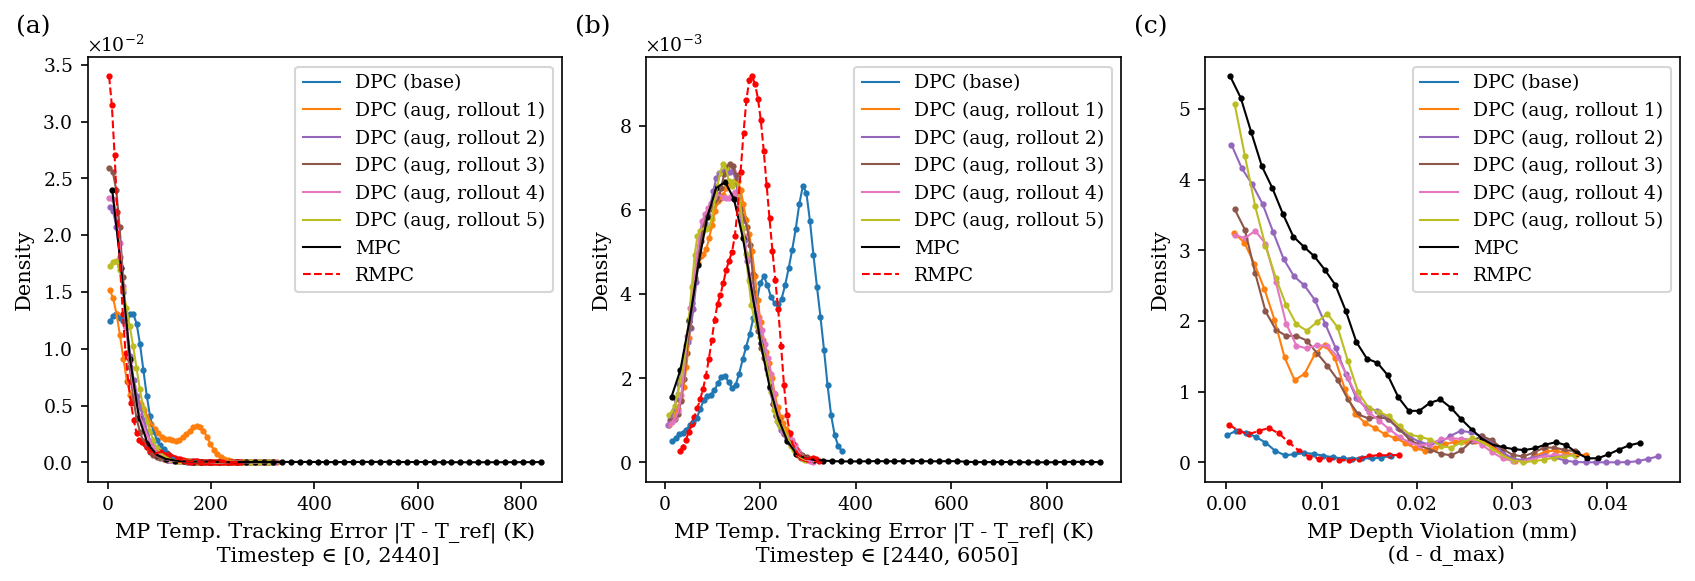


===== FINAL STATS =====
                 method  temp1_mean   temp1_std  temp2_mean   temp2_std  \
1  DPC (aug, rollout 1)   69.395163   70.239597  134.039355   63.769330   
2  DPC (aug, rollout 2)   31.734790   44.119864  128.228848   63.229613   
3  DPC (aug, rollout 3)   27.249831   42.953082  130.872957   62.839565   
4  DPC (aug, rollout 4)   30.828414   44.309945  130.661194   64.207072   
5  DPC (aug, rollout 5)   36.726592   44.584219  126.855305   63.545367   
0            DPC (base)   44.431426   44.780956  227.291323   84.240596   
6                   MPC   32.931560  105.914383  134.021750  111.551154   
7                  RMPC   25.613327   43.038770  171.074684   56.969334   

   viol_mean  viol_std  viol_count  viol_rate  
1   0.008305  0.007972         193   0.031906  
2   0.007950  0.007194         274   0.045297  
3   0.008523  0.008158         205   0.033890  
4   0.008375  0.007098         211   0.034882  
5   0.007653  0.006817         260   0.042982  
0   0.00524

In [47]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker

# ===== 경로 =====
base_pattern = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/addnoise"

mpc_csv  = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_MPC_w_depth_control_0925.csv"
rmpc_csv = "/home/ftk3187/github/DPC_research/02_DED/0_MPC_noise/profile_1_RMPC_w_depth_control.csv"
base_paths = glob.glob(base_pattern)

epochs = ["0049", "0099", "0149", "0199", "0249", "0299"]
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#8c564b", "#e377c2", "#bcbd22"]

laser_range = range(1, 2)

LINEWIDTH = 1
dot = 4

# ===== 통계 저장 =====
results = []

def collect_stats(name, p1, p2, depth):
    v = depth - 0.225
    v = v[v > 0]

    results.append({
        "method": name,
        "temp1_mean": np.mean(p1),
        "temp1_std": np.std(p1),
        "temp2_mean": np.mean(p2),
        "temp2_std": np.std(p2),
        "viol_mean": np.mean(v) if len(v) > 0 else 0,
        "viol_std": np.std(v) if len(v) > 0 else 0,
        "viol_count": len(v),
        "viol_rate": len(v) / len(depth)
    })

# ===== helper =====
def hist_line(ax, data, color, label, linestyle='-'):
    if len(data) == 0:
        return

    p_low = np.percentile(data, 0.5)
    p_high = np.percentile(data, 99.5)
    bins = np.linspace(p_low, p_high, 50)

    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    hist = gaussian_filter1d(hist, sigma=1.2)

    ax.plot(centers, hist, color=color, linewidth=LINEWIDTH,
            linestyle=linestyle, label=label)
    ax.scatter(centers, hist, color=color, s=dot)

def plot_violation(ax, depth, color, label, linestyle='-'):
    all_data = depth - 0.225

    bins = np.linspace(np.min(all_data), np.max(all_data), 800)
    hist, edges = np.histogram(all_data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    hist = gaussian_filter1d(hist, sigma=1.2)

    mask = centers > 0

    ax.plot(centers[mask], hist[mask],
            color=color, linestyle=linestyle,
            linewidth=LINEWIDTH, label=label)
    ax.scatter(centers[mask], hist[mask], color=color, s=dot)

# ===== label =====
def get_label(epoch):
    if epoch == "0049":
        return "DPC (base)"
    else:
        rollout = epochs.index(epoch)
        return f"DPC (aug, rollout {rollout})"

# ===== MPC =====
df_mpc = pd.read_csv(mpc_csv)

mpc_temp = df_mpc["gamma_result_temp"].values[:-1] / 2   # 🔥 수정
mpc_ref  = df_mpc["ref"].values[:-1] / 2                 # 🔥 수정
mpc_depth = df_mpc["gamma_result_depth"].values[:-1]

mpc_dist = np.abs(mpc_temp - mpc_ref)
mpc_p1 = mpc_dist[:2440]
mpc_p2 = mpc_dist[2440:6050]

# ===== RMPC =====
df_rmpc = pd.read_csv(rmpc_csv)

rmpc_temp = df_rmpc["gamma_result_temp"].values[:-1] / 2  # 🔥 수정
rmpc_ref  = df_rmpc["ref"].values[:-1] / 2                # 🔥 수정
rmpc_depth = df_rmpc["gamma_result_depth"].values[:-1]

rmpc_dist = np.abs(rmpc_temp - rmpc_ref)
rmpc_p1 = rmpc_dist[:2440]
rmpc_p2 = rmpc_dist[2440:6050]

# ===== main =====
for base_path in base_paths:
    print(f"\n📂 {base_path}")

    for laser_id in laser_range:

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        for i, epoch in enumerate(epochs):

            folder = os.path.join(base_path, f"policy_roll_epoch{epoch}.pth_clamped(1)")

            ref_file = os.path.join(folder, f"ref_laser_{laser_id}.csv")
            temp_file = os.path.join(folder, f"x_outputs_laser_{laser_id}.csv")

            if not os.path.exists(ref_file):
                continue

            ref = pd.read_csv(ref_file, header=None).iloc[:, 0].values / 2  # 🔥 수정
            df_temp = pd.read_csv(temp_file)

            temp = df_temp.iloc[:, 0].values / 2  # 🔥 수정
            depth = df_temp.iloc[:, 1].values

            ref = ref[1:6050]
            temp = temp[:6050]
            depth = depth[:6050]

            min_len = min(len(ref), len(temp), len(depth))
            ref = ref[:min_len]
            temp = temp[:min_len]
            depth = depth[:min_len]

            dist = np.abs(temp - ref)

            label = get_label(epoch)

            # ===== plot =====
            hist_line(axes[0], dist[:2440], colors[i], label)
            hist_line(axes[1], dist[2440:6050], colors[i], label)
            plot_violation(axes[2], depth, colors[i], label)

            # ===== stats =====
            collect_stats(label, dist[:2440], dist[2440:6050], depth)

        # ===== MPC / RMPC =====
        hist_line(axes[0], mpc_p1, 'black', "MPC")
        hist_line(axes[1], mpc_p2, 'black', "MPC")
        plot_violation(axes[2], mpc_depth, 'black', "MPC")

        hist_line(axes[0], rmpc_p1, 'r', "RMPC", linestyle='--')
        hist_line(axes[1], rmpc_p2, 'r', "RMPC", linestyle='--')
        plot_violation(axes[2], rmpc_depth, 'r', "RMPC", linestyle='--')

        collect_stats("MPC", mpc_p1, mpc_p2, mpc_depth)
        collect_stats("RMPC", rmpc_p1, rmpc_p2, rmpc_depth)

        # ===== xlabel =====
        axes[0].set_xlabel("MP Temp. Tracking Error |T - T_ref| (K)\n Timestep ∈ [0, 2440]")
        axes[1].set_xlabel("MP Temp. Tracking Error |T - T_ref| (K)\n Timestep ∈ [2440, 6050]")
        axes[2].set_xlabel("MP Depth Violation (mm)\n (d - d_max)")

        for i, ax in enumerate(axes):
            ax.set_ylabel("Density")
            if i < 2:
                ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
                ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

        # ===== legend =====
        for ax in axes:
            ax.legend()

        # ===== (a)(b)(c) =====
        labels = ['(a)', '(b)', '(c)']
        for i, ax in enumerate(axes):
            ax.text(-0.15, 1.1, labels[i],
                    transform=ax.transAxes,
                    fontsize=12,
                    va='top', ha='left')

        plt.tight_layout(rect=[0.05, 0, 1, 1])
        plt.show()

# ===== 결과 저장 =====
df = pd.DataFrame(results)
df = df.sort_values("method")

print("\n===== FINAL STATS =====")
print(df)

df.to_csv("comparison_stats.csv", index=False)

DPC - n=6195, mean=6.0892e-04, median=5.8007e-04
MPC - n=6196, mean=1.6439e+00, median=3.3009e-01


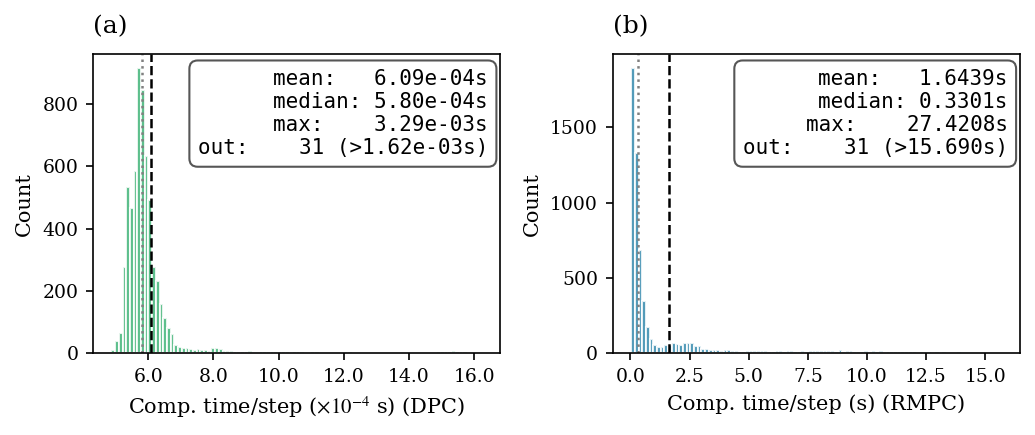

In [40]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker

# ── 경로 ──
dpc_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/time/policy_roll_epoch0199.pth_clamped(1)"
mpc_dir = "/home/ftk3187/github/DPC_research/02_DED/0_MPC"

# ── 데이터 로드 ──
dpc_times = pd.read_csv(os.path.join(dpc_dir, "policy_time_laser_1.csv"))['Time'].values
mpc_times = pd.read_csv(os.path.join(mpc_dir, "profile_1_RMPC_w_depth_control.csv"))['Time'].values

print(f"DPC - n={len(dpc_times)}, mean={np.mean(dpc_times):.4e}, median={np.median(dpc_times):.4e}")
print(f"MPC - n={len(mpc_times)}, mean={np.mean(mpc_times):.4e}, median={np.median(mpc_times):.4e}")

# ── 컬러 ──
C1  = '#2E86AB'
C2  = '#E84855'
CU  = '#3BB273'
LABEL_SIZE = 12

import matplotlib as mpl

# ── 폰트/스타일 설정 (플롯 코드 최상단에) ──
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        150,
    'axes.spines.top':   True,
    'axes.spines.right': True,
})

# ── plot_hist 함수 ──
def plot_hist(ax, times, color, subplot_label,
              use_scientific=False,
              label_size=12,
              stat_size=10):

    p995    = np.percentile(times, 99.5)
    clipped = times[times <= p995]
    n_out   = np.sum(times > p995)

    ax.hist(clipped, bins=100, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(times.mean(),     color='k',    lw=1.2, ls='--')
    ax.axvline(np.median(times), color='gray', lw=1.2, ls=':')

    if use_scientific:
        # ── x축 단위를 1e-4 로 나눠서 표시 ──
        scale = 1e-4
        ax.xaxis.set_major_formatter(
            mpl.ticker.FuncFormatter(lambda x, _: f'{x/scale:.1f}')
        )
        ax.set_xlabel(r'Comp. time/step ($\times 10^{-4}$ s) (DPC)')
        stats_text = (f'mean:   {times.mean():.2e}s\n'
                      f'median: {np.median(times):.2e}s\n'
                      f'max:    {times.max():.2e}s\n'
                      f'out:    {n_out} (>{p995:.2e}s)')
    else:
        stats_text = (f'mean:   {times.mean():.4f}s\n'
                      f'median: {np.median(times):.4f}s\n'
                      f'max:    {times.max():.4f}s\n'
                      f'out:    {n_out} (>{p995:.3f}s)')

    ax.text(
        0.97, 0.95, stats_text,
        transform=ax.transAxes,
        fontsize=stat_size,
        va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='0.3', alpha=0.95),
        fontfamily='monospace'
    )

    ax.set_ylabel('Count')

    ax.set_ylabel('Count')
    # ── 축 바깥 상단 왼쪽에 (a)/(b) ──
    ax.set_title(subplot_label, fontsize=label_size, loc='left', pad=10)

# ── Figure: 좌우 2열 ──
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(7, 3))

# (a) DPC
plot_hist(ax_a, dpc_times, CU, '(a)', use_scientific=True)
# ax_a.set_xlabel(...)  ← 제거! 함수 안에서 처리

# (b) MPC
plot_hist(ax_b, mpc_times, C1, '(b)', use_scientific=False)
ax_b.set_xlabel('Comp. time/step (s) (RMPC)')

plt.tight_layout()
plt.savefig('time_histogram.pdf', bbox_inches='tight', dpi=300)
plt.show()